# Tesla Stock Market - ML Classification Project
**Target:** Predict whether Tesla's closing price will go **Up (1) or Down (0)** the next day

## Step 0: Install Dependencies

In [1]:
!pip install imbalanced-learn -q
print('Done!')

Done!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                               GradientBoostingClassifier, BaggingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported!')

All libraries imported!


## 2. Load Dataset

In [3]:
df = pd.read_csv('tesla.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (1692, 7)


,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
5,7/7/2010,16.400000,16.629999,14.980000,15.800000,6921700,15.800000
6,7/8/2010,16.139999,17.520000,15.570000,17.459999,7711400,17.459999
7,7/9/2010,17.580000,17.900000,16.549999,17.400000,4050600,17.400000
8,7/12/2010,17.950001,18.070000,17.000000,17.049999,2202500,17.049999
9,7/13/2010,17.389999,18.639999,16.900000,18.139999,2680100,18.139999


## 3. Data Preprocessing - Null Value Check & Replacement

In [4]:
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   str    
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 92.7 KB

=== Basic Statistics ===


,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [5]:
# Check null values
print('=== Null Values Before Replacement ===')
print(df.isnull().sum())
print(f'Total nulls: {df.isnull().sum().sum()}')

=== Null Values Before Replacement ===
Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64
Total nulls: 0


=== Null Values After Replacing Empty Strings with NaN ===
Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64
Total NaN: 0


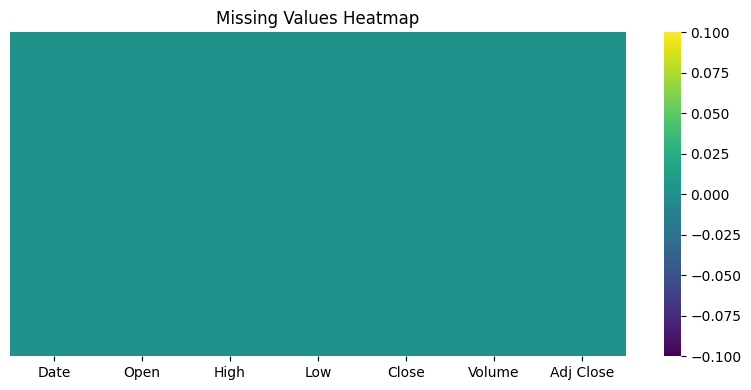

In [6]:
# Replace any empty strings or whitespace with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

print('=== Null Values After Replacing Empty Strings with NaN ===')
print(df.isnull().sum())
print(f'Total NaN: {df.isnull().sum().sum()}')

# Visualize missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## 4. Feature Engineering - Create Target Variable

In [7]:
# Parse date and sort
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Target: 1 if next day Close > today's Close, else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Add technical features
df['Price_Change']   = df['Close'] - df['Open']
df['High_Low_Range'] = df['High'] - df['Low']
df['Daily_Return']   = df['Close'].pct_change()
df['MA_5']           = df['Close'].rolling(window=5).mean()
df['MA_10']          = df['Close'].rolling(window=10).mean()
df['Volatility']     = df['Close'].rolling(window=5).std()

# Drop Date column and last row (no target for it)
df.drop(columns=['Date'], inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape after feature engineering:', df.shape)
df.head()

Shape after feature engineering: (1683, 13)


,Open,High,Low,Close,Volume,Adj Close,Target,Price_Change,High_Low_Range,Daily_Return,MA_5,MA_10,Volatility
0,17.389999,18.639999,16.900000,18.139999,2680100,18.139999,1,0.750000,1.739999,0.063930,17.169999,19.084,0.861568
1,17.940001,20.150000,17.760000,19.840000,4195200,19.840000,1,1.899999,2.390000,0.093716,17.977999,18.679,1.113203
2,19.940001,21.500000,19.000000,19.889999,3739800,19.889999,1,-0.050002,2.500000,0.002520,18.463999,18.285,1.338219
3,20.700001,21.299999,20.049999,20.639999,2621300,20.639999,1,-0.060002,1.250000,0.037707,19.111999,18.153,1.471961
4,21.370001,22.250000,20.920000,21.910000,2486500,21.910000,0,0.539999,1.330000,0.061531,20.083999,18.424,1.371106


## 5. Class Balance Check & SMOTE Oversampling

=== Class Distribution (Before Balancing) ===
Target
1    864
0    819
Name: count, dtype: int64

0 = Price Down: 819
1 = Price Up:   864


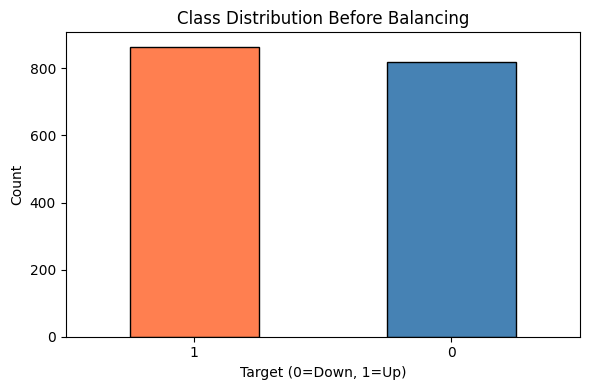

In [8]:
print('=== Class Distribution (Before Balancing) ===')
print(df['Target'].value_counts())
print(f"\n0 = Price Down: {df['Target'].value_counts()[0]}")
print(f"1 = Price Up:   {df['Target'].value_counts()[1]}")

plt.figure(figsize=(6, 4))
df['Target'].value_counts().plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.title('Class Distribution Before Balancing')
plt.xlabel('Target (0=Down, 1=Up)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Class Distribution After SMOTE ===
Target
1    864
0    864
Name: count, dtype: int64


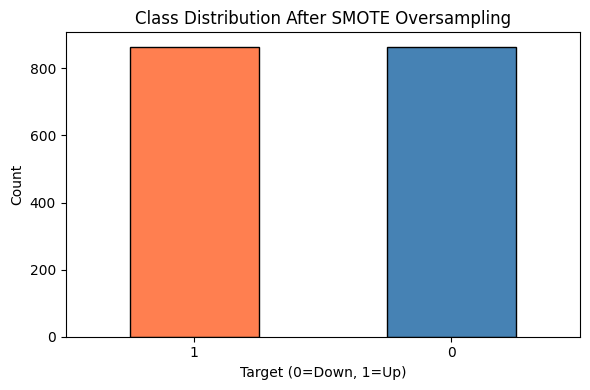

In [9]:
X = df.drop('Target', axis=1)
y = df['Target']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print('=== Class Distribution After SMOTE ===')
print(pd.Series(y_res).value_counts())

plt.figure(figsize=(6, 4))
pd.Series(y_res).value_counts().plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.title('Class Distribution After SMOTE Oversampling')
plt.xlabel('Target (0=Down, 1=Up)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Outlier Detection (Boxplot) & Removal (Z-Score)

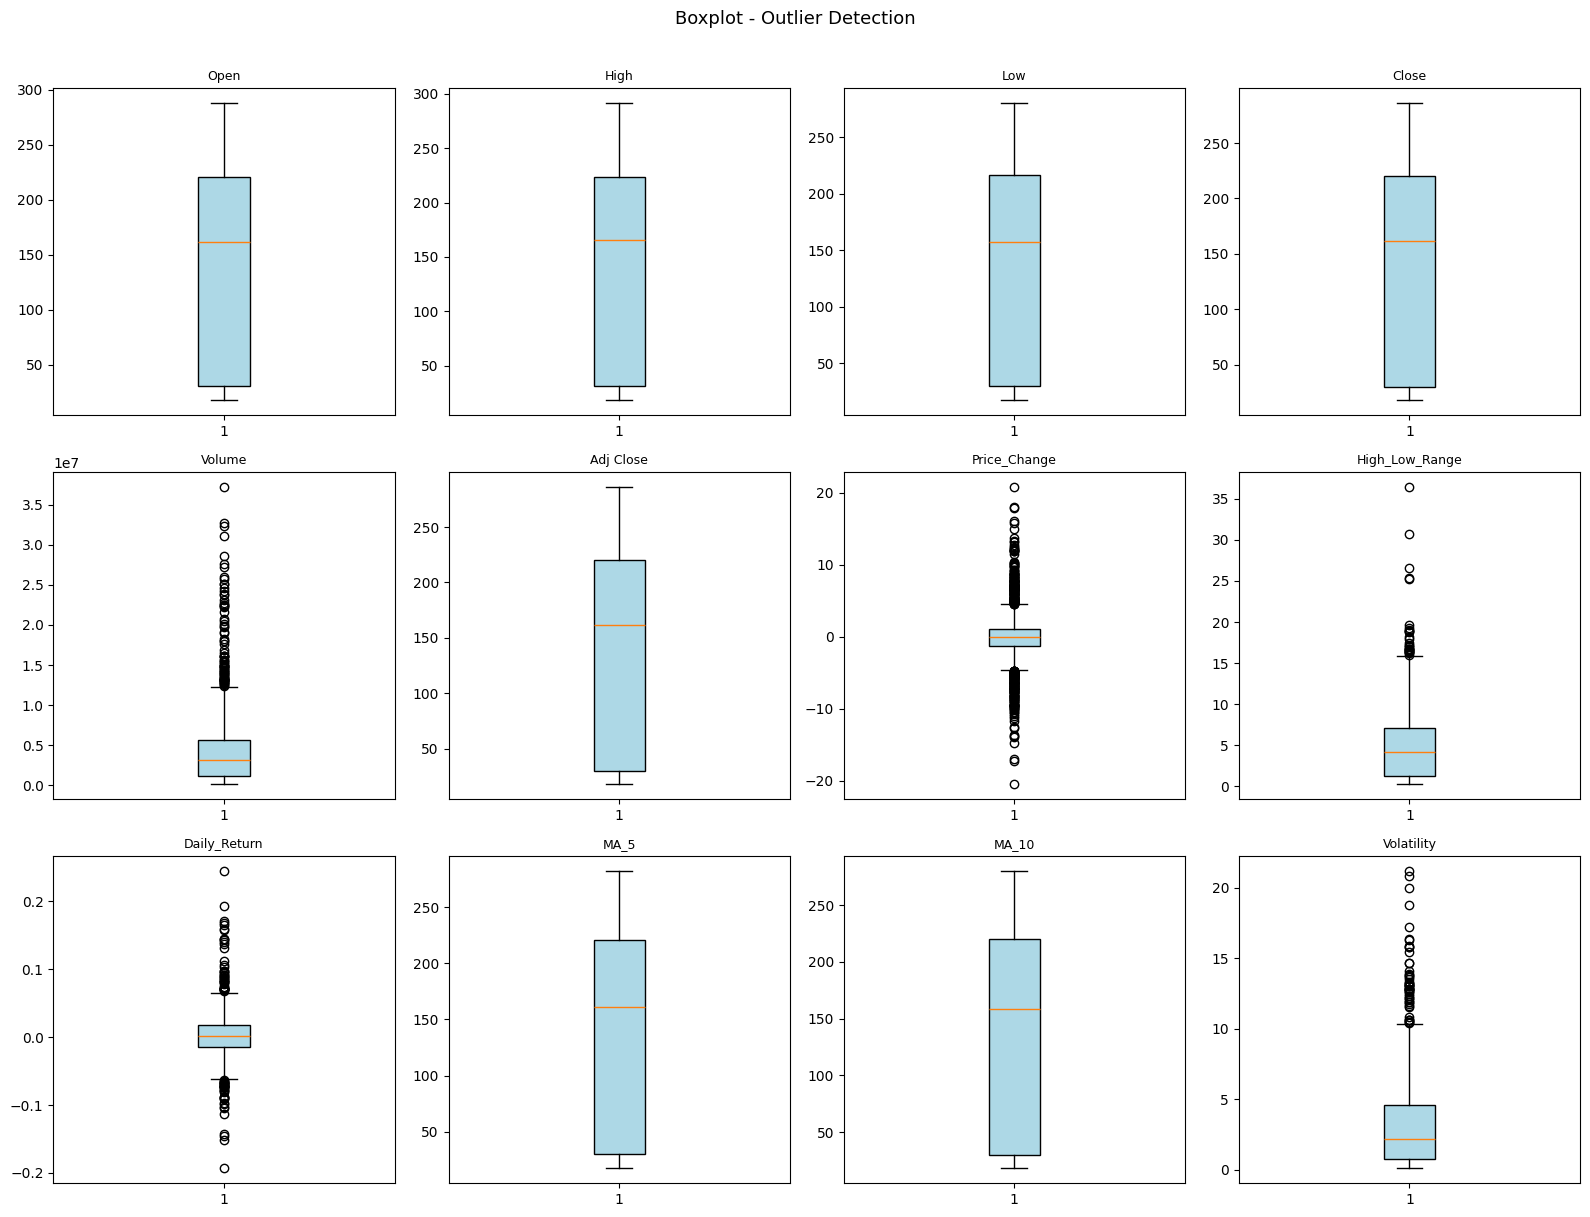

In [10]:
# Boxplot for outlier visualization
feature_cols = X_res.columns.tolist()
n = len(feature_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(16, rows * 4))
for i, col in enumerate(feature_cols):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.boxplot(X_res[col], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
    plt.title(col, fontsize=9)
plt.suptitle('Boxplot - Outlier Detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Remove outliers using Z-Score (threshold = 3)
df_combined = pd.DataFrame(X_res, columns=X.columns)
df_combined['Target'] = y_res.values

z_scores = np.abs(stats.zscore(df_combined.select_dtypes(include='number')))
mask = (z_scores < 3).all(axis=1)
df_clean = df_combined[mask].reset_index(drop=True)

print(f'Rows before outlier removal: {len(df_combined)}')
print(f'Rows after outlier removal:  {len(df_clean)}')
print(f'Outliers removed: {len(df_combined) - len(df_clean)}')

Rows before outlier removal: 1728
Rows after outlier removal:  1635
Outliers removed: 93


## 7. Correlation Heatmap & Feature Analysis

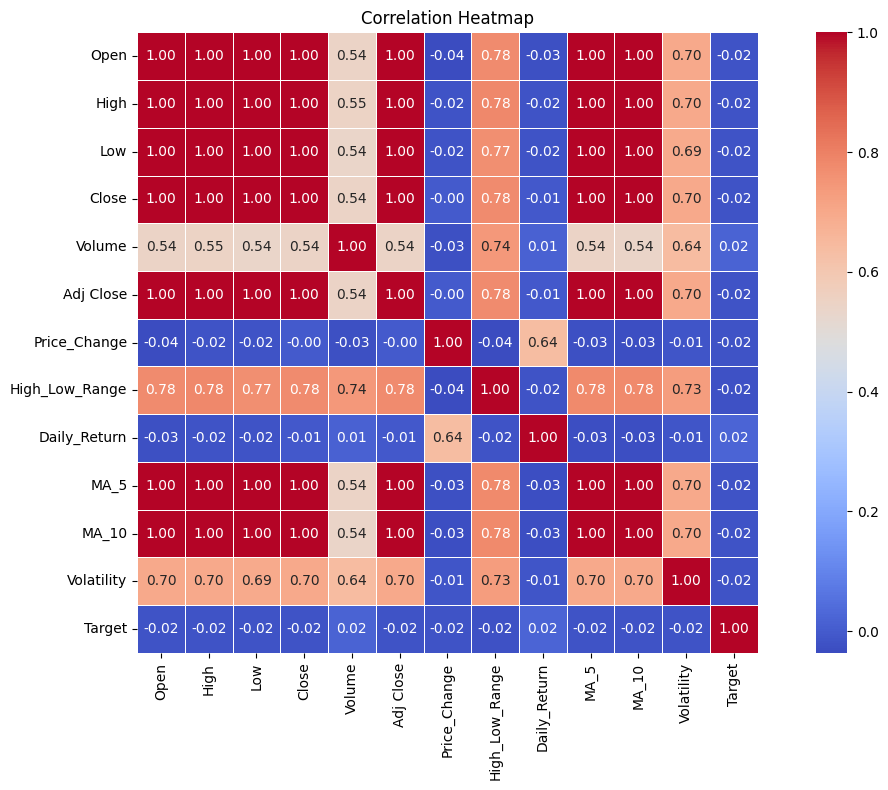

In [12]:
plt.figure(figsize=(12, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

=== Feature Correlation with Target ===
Daily_Return      0.023126
Volume            0.019396
Price_Change     -0.016553
Open             -0.018833
Volatility       -0.018956
Low              -0.019128
MA_10            -0.019371
Close            -0.019385
Adj Close        -0.019385
High             -0.019465
MA_5             -0.019682
High_Low_Range   -0.024170
Name: Target, dtype: float64


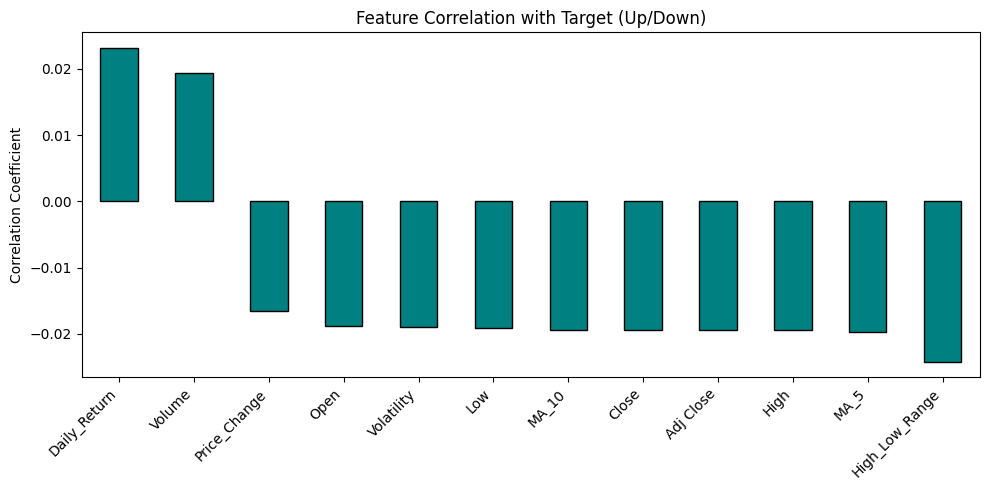

In [13]:
# Feature correlation with target
target_corr = corr['Target'].drop('Target').sort_values(ascending=False)
print('=== Feature Correlation with Target ===')
print(target_corr)

plt.figure(figsize=(10, 5))
target_corr.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Correlation with Target (Up/Down)')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Train-Test Split & Feature Scaling

In [14]:
X_final = df_clean.drop('Target', axis=1)
y_final = df_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1308, 12) | Test: (327, 12)


## 9. Model Training & Evaluation

In [15]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    cm  = confusion_matrix(y_te, y_pred)

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'Accuracy: {acc*100:.2f}%')
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Down (0)', 'Up (1)']))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    return acc

results = {}

### 9.1 Logistic Regression


  Logistic Regression
Accuracy: 50.46%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.51      0.49      0.50       164
      Up (1)       0.50      0.52      0.51       163

    accuracy                           0.50       327
   macro avg       0.50      0.50      0.50       327
weighted avg       0.50      0.50      0.50       327



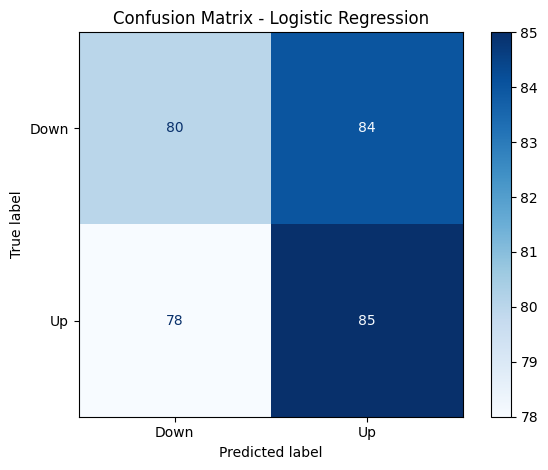

In [16]:
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.2 AdaBoost


  AdaBoost
Accuracy: 47.71%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.47      0.38      0.42       164
      Up (1)       0.48      0.58      0.52       163

    accuracy                           0.48       327
   macro avg       0.48      0.48      0.47       327
weighted avg       0.48      0.48      0.47       327



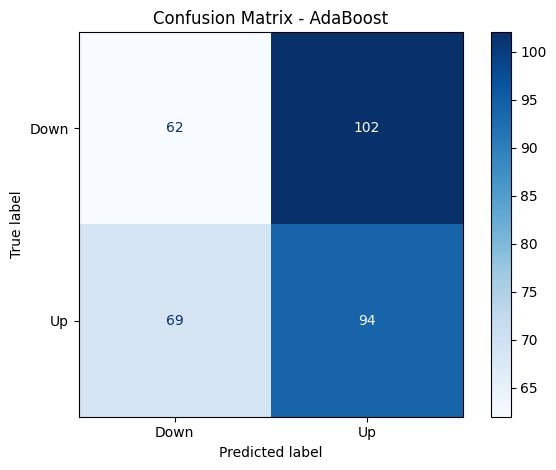

In [17]:
results['AdaBoost'] = evaluate_model(
    'AdaBoost',
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.3 K-Nearest Neighbours


  K-Nearest Neighbours (k=5)
Accuracy: 52.29%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.53      0.51      0.52       164
      Up (1)       0.52      0.54      0.53       163

    accuracy                           0.52       327
   macro avg       0.52      0.52      0.52       327
weighted avg       0.52      0.52      0.52       327



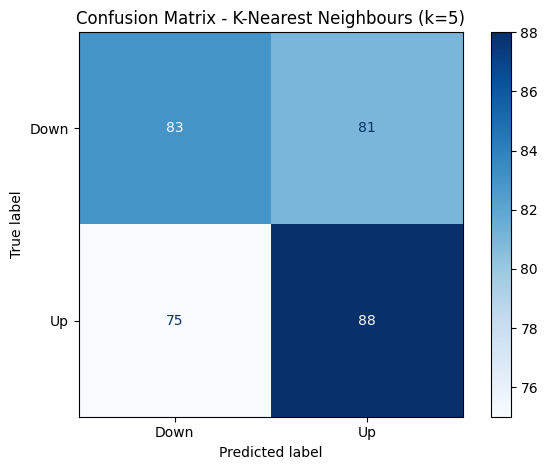

In [18]:
results['KNN'] = evaluate_model(
    'K-Nearest Neighbours (k=5)',
    KNeighborsClassifier(n_neighbors=5),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.4 Random Forest


  Random Forest
Accuracy: 48.62%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.49      0.53      0.51       164
      Up (1)       0.48      0.44      0.46       163

    accuracy                           0.49       327
   macro avg       0.49      0.49      0.49       327
weighted avg       0.49      0.49      0.49       327



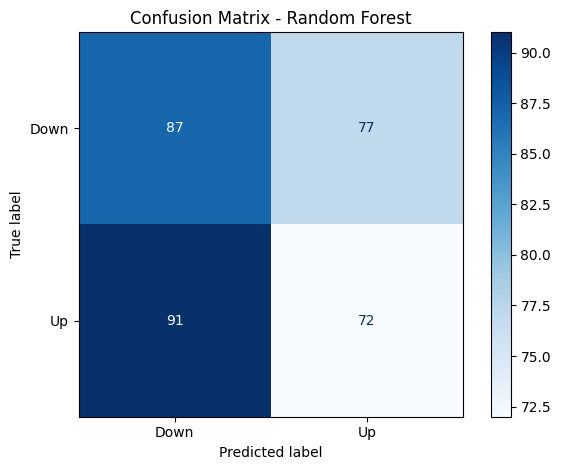

In [19]:
results['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.5 Decision Tree


  Decision Tree
Accuracy: 46.79%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.47      0.45      0.46       164
      Up (1)       0.47      0.49      0.48       163

    accuracy                           0.47       327
   macro avg       0.47      0.47      0.47       327
weighted avg       0.47      0.47      0.47       327



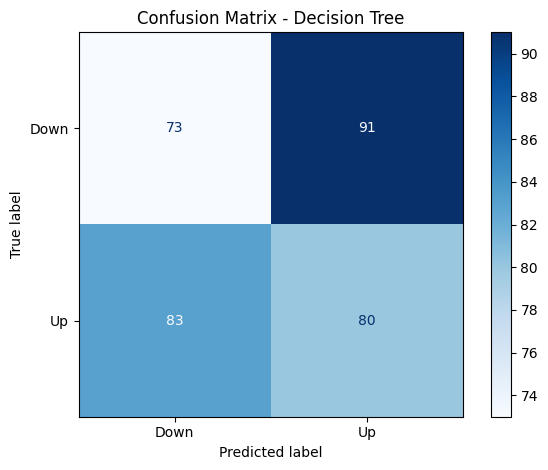

In [20]:
results['Decision Tree'] = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.6 Support Vector Machine


  Support Vector Machine
Accuracy: 48.32%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.31      0.38       164
      Up (1)       0.49      0.66      0.56       163

    accuracy                           0.48       327
   macro avg       0.48      0.48      0.47       327
weighted avg       0.48      0.48      0.47       327



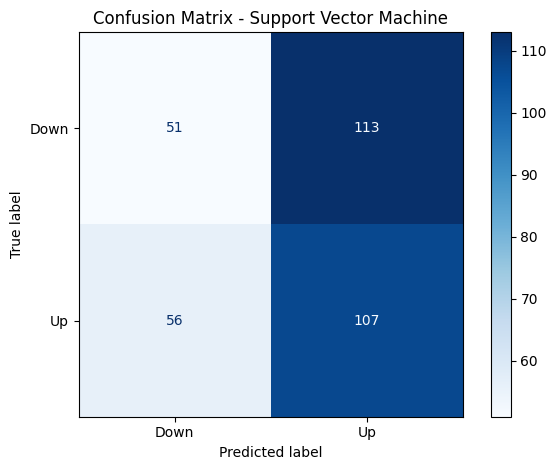

In [21]:
results['SVM'] = evaluate_model(
    'Support Vector Machine',
    SVC(kernel='rbf', random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.7 Naive Bayes


  Naive Bayes
Accuracy: 52.60%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.53      0.45      0.49       164
      Up (1)       0.52      0.61      0.56       163

    accuracy                           0.53       327
   macro avg       0.53      0.53      0.52       327
weighted avg       0.53      0.53      0.52       327



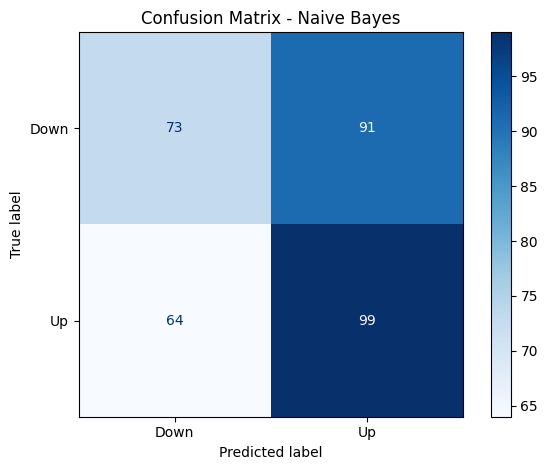

In [22]:
results['Naive Bayes'] = evaluate_model(
    'Naive Bayes',
    GaussianNB(),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.8 Gradient Boosting


  Gradient Boosting
Accuracy: 46.79%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.47      0.46      0.46       164
      Up (1)       0.47      0.48      0.47       163

    accuracy                           0.47       327
   macro avg       0.47      0.47      0.47       327
weighted avg       0.47      0.47      0.47       327



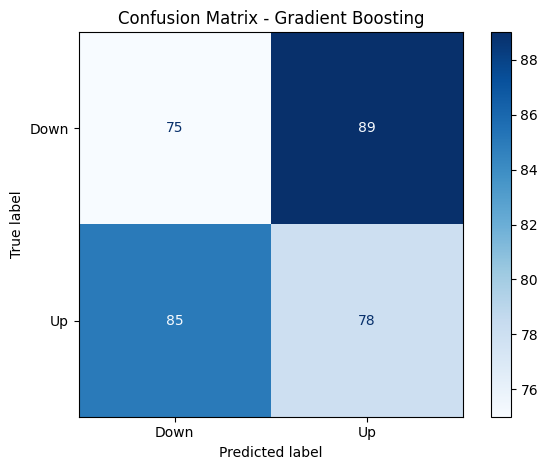

In [23]:
results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

### 9.9 Bagging Classifier


  Bagging Classifier
Accuracy: 47.71%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.50      0.49       164
      Up (1)       0.47      0.45      0.46       163

    accuracy                           0.48       327
   macro avg       0.48      0.48      0.48       327
weighted avg       0.48      0.48      0.48       327



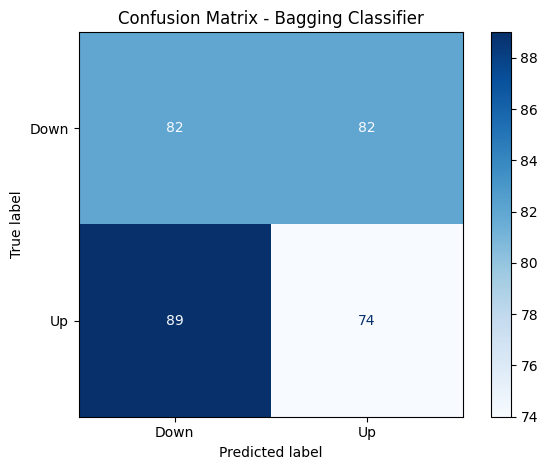

In [24]:
results['Bagging'] = evaluate_model(
    'Bagging Classifier',
    BaggingClassifier(n_estimators=100, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
)

## 10. Model Comparison Summary

=== Model Accuracy Comparison ===
          Algorithm  Accuracy (%)
        Naive Bayes         52.60
                KNN         52.29
Logistic Regression         50.46
      Random Forest         48.62
                SVM         48.32
            Bagging         47.71
           AdaBoost         47.71
      Decision Tree         46.79
  Gradient Boosting         46.79


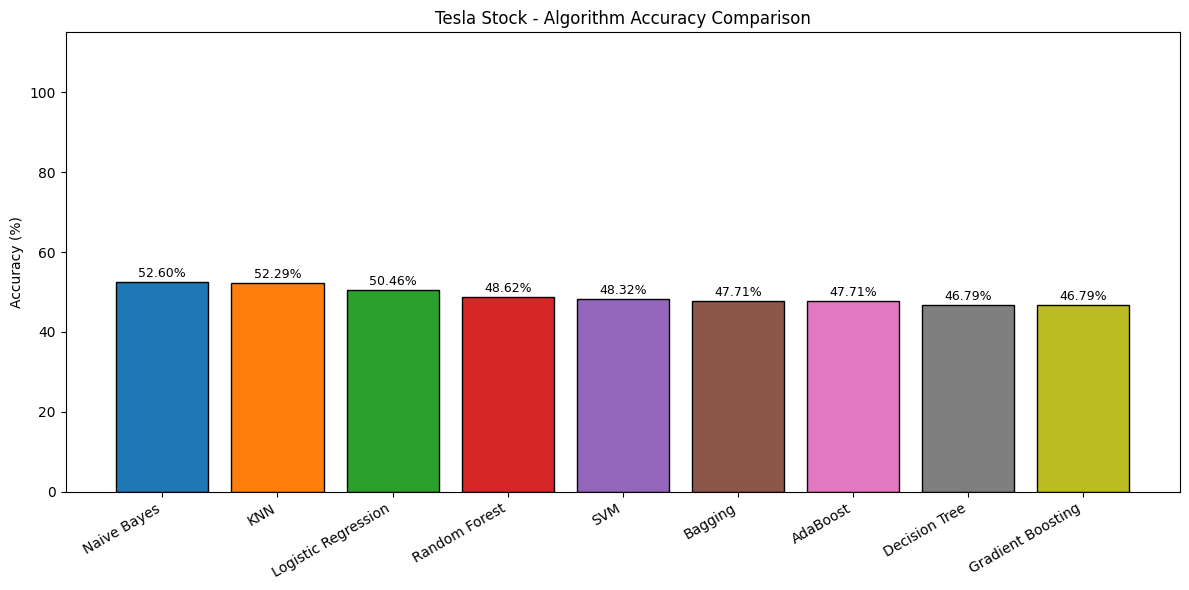


Best Model: Naive Bayes with 52.60% accuracy


In [25]:
results_df = pd.DataFrame(list(results.items()), columns=['Algorithm', 'Accuracy'])
results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print('=== Model Accuracy Comparison ===')
print(results_df[['Algorithm', 'Accuracy (%)']].to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Algorithm'], results_df['Accuracy (%)'],
               color=plt.cm.tab10.colors[:len(results_df)], edgecolor='black')
plt.ylim(0, 115)
plt.ylabel('Accuracy (%)')
plt.title('Tesla Stock - Algorithm Accuracy Comparison')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f'\nBest Model: {best["Algorithm"]} with {best["Accuracy (%)"]:.2f}% accuracy')

## 11. Metrics Summary Table (Saved as Image)

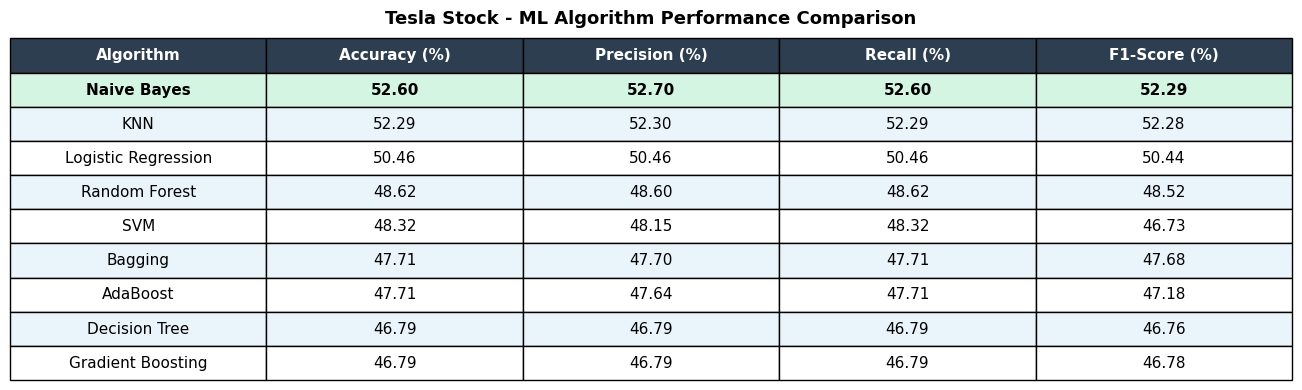

Saved as metrics_table.png


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'Naive Bayes':         GaussianNB(),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42)
}

metrics_list = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    metrics_list.append({
        'Algorithm': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='weighted') * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted') * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted') * 100, 2)
    })

metrics_df = pd.DataFrame(metrics_list).sort_values('Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

col_labels = ['Algorithm', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
table_data = metrics_df.values.tolist()
table_data = [[row[0]] + [f'{v:.2f}' for v in row[1:]] for row in table_data]

table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    color = '#eaf4fb' if i % 2 == 0 else '#ffffff'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

for j in range(len(col_labels)):
    table[1, j].set_facecolor('#d5f5e3')
    table[1, j].set_text_props(fontweight='bold')

plt.title('Tesla Stock - ML Algorithm Performance Comparison', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as metrics_table.png')